In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np


In [2]:
df = pd.read_csv('../data/HAM10000_metadata.csv')
print(df.head())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


In [3]:
def bar_graph(counts, title, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(9, 6))

    bars = ax.bar(counts.index, counts.values, alpha=0.85, edgecolor='white', width=0.6)

    # Add count labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

    # Labels and title
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

    # Rotate x labels if they're long, otherwise keep flat
    plt.xticks(rotation=0)

    # Grid and styling
    ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='gray')
    ax.set_axisbelow(True)
    ax.set_facecolor('#F9F9F9')
    fig.patch.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

In [10]:
# Check if dx_type is consistent within each lesion
dx_type_per_lesion = df.groupby('lesion_id')['dx_type'].nunique()

# Lesions with more than one distinct dx_type
inconsistent_lesions = dx_type_per_lesion[dx_type_per_lesion > 1]

print(f"Total lesions: {df['lesion_id'].nunique()}")
print(f"Lesions with inconsistent dx_type: {len(inconsistent_lesions)}")

if len(inconsistent_lesions) > 0:
    print("\nExample inconsistent lesions:")
    example_ids = inconsistent_lesions.index[:5]
    print(df[df['lesion_id'].isin(example_ids)][['lesion_id', 'image_id', 'dx_type']].sort_values('lesion_id'))
else:
    print("\nAll lesions have a single, consistent dx_type across their images.")

Total lesions: 7470
Lesions with inconsistent dx_type: 0

All lesions have a single, consistent dx_type across their images.


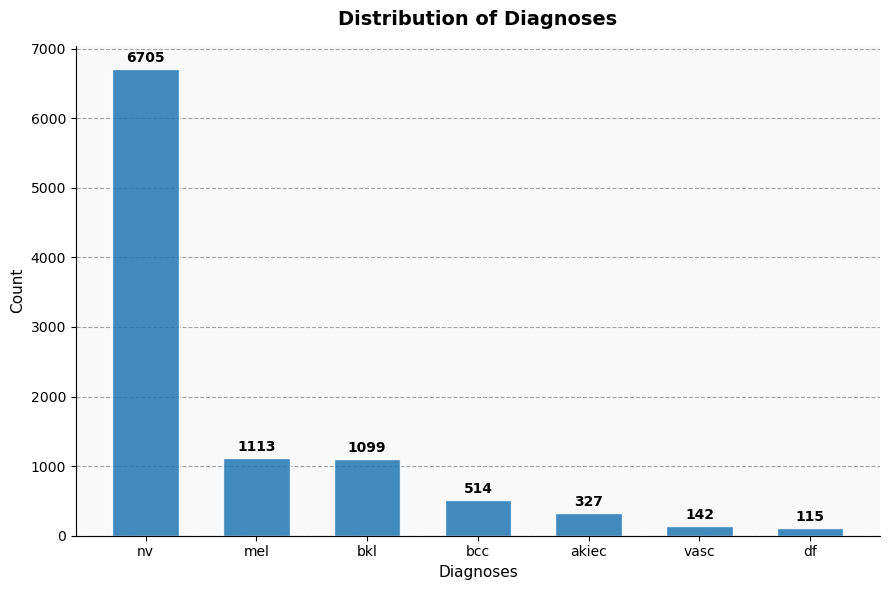

In [5]:
counts = df['dx'].value_counts()

bar_graph(counts, 'Distribution of Diagnoses', 'Diagnoses', 'Count')

In [6]:
print("Number of Unique Lesions: ", df['lesion_id'].nunique())
print("Number of Images: ", len(df))

Number of Unique Lesions:  7470
Number of Images:  10015


In [7]:
unique_lesion_df = df.drop_duplicates(subset='lesion_id')

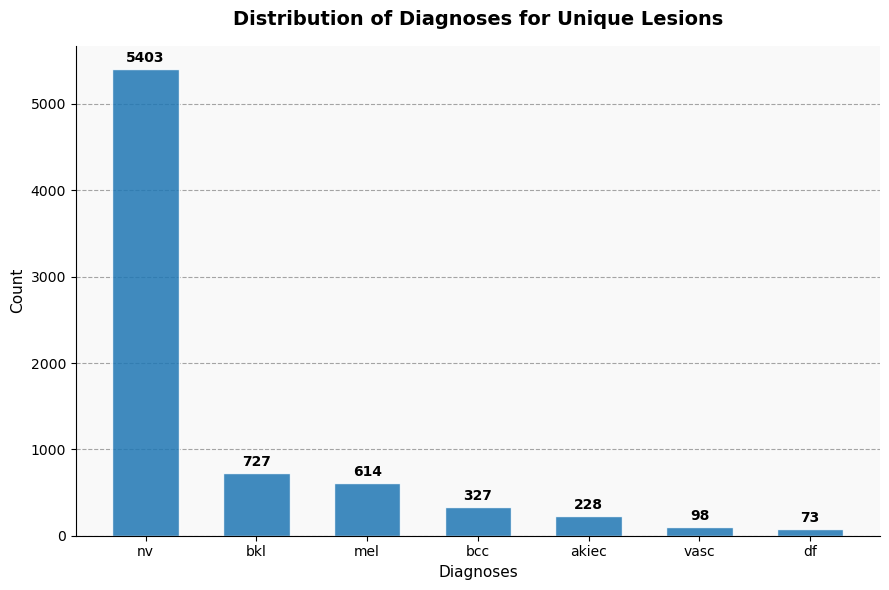

In [8]:
counts = unique_lesion_df['dx'].value_counts()

bar_graph(counts, 'Distribution of Diagnoses for Unique Lesions', 'Diagnoses', 'Count')

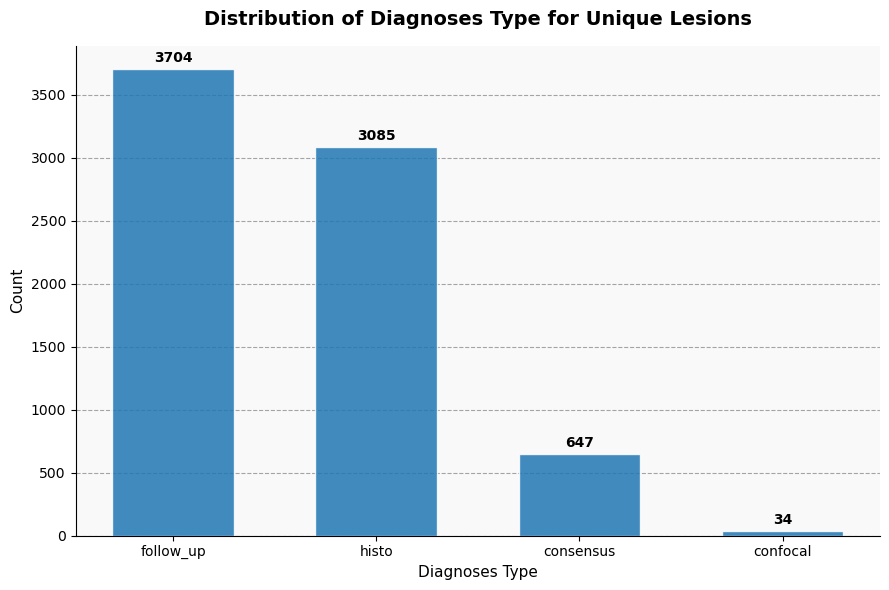

In [11]:
counts = unique_lesion_df['dx_type'].value_counts()

bar_graph(counts, 'Distribution of Diagnoses Type for Unique Lesions', 'Diagnoses Type', 'Count')

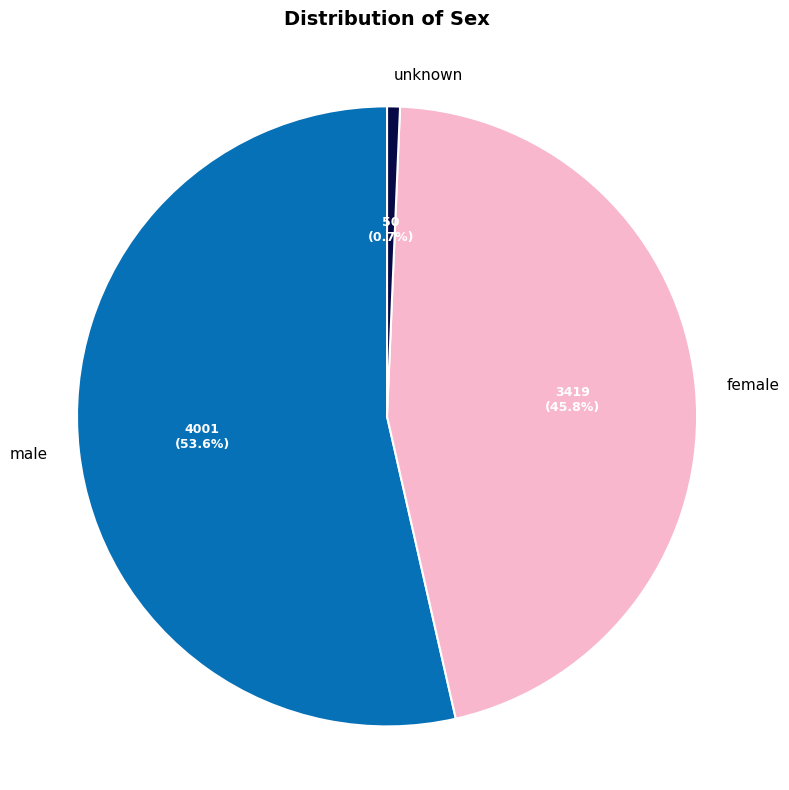

In [12]:
counts = unique_lesion_df['sex'].value_counts()
total = counts.sum()

# Custom label function to show count + percent
def make_autopct(counts):
    def autopct(pct):
        count = int(round(pct * total / 100.0))
        return f"{count}\n({pct:.1f}%)"
    return autopct

fig, ax = plt.subplots(figsize=(8,8))
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=counts.index,
    autopct=make_autopct(counts),
    colors=("#0671B7", "#F8B7CD", "#060945"),
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 10}
)

plt.setp(autotexts, size=9, weight='bold', color='white')
plt.setp(texts, size=11)

ax.set_title("Distribution of Sex", fontsize=14, weight='bold', pad=20)
ax.axis('equal')

plt.tight_layout()
plt.show()


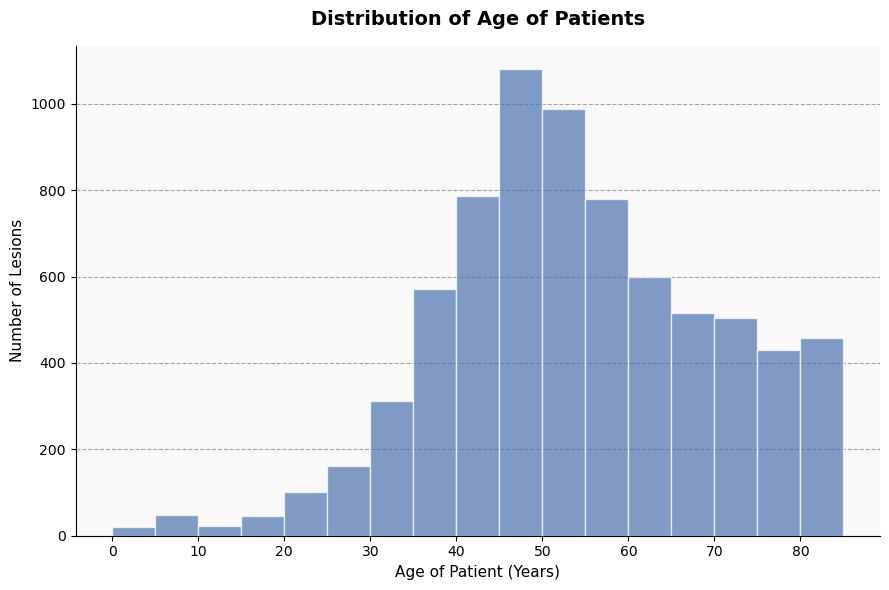

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))

age_min = np.floor(unique_lesion_df["age"].min() / 5) * 5
age_max = np.ceil(unique_lesion_df["age"].max() / 5) * 5
bins = np.arange(age_min, age_max + 5, 5)

ax.hist(unique_lesion_df["age"], bins=bins, color='#4C72B0', alpha=0.7, edgecolor='white')

# Labels and title
ax.set_title('Distribution of Age of Patients', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Age of Patient (Years)', fontsize=11)
ax.set_ylabel('Number of Lesions', fontsize=11)



# More x tick labels — every 5 or 10 years
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))

# Grid and styling
ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='gray')
ax.set_axisbelow(True)
ax.set_facecolor('#F9F9F9')
fig.patch.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [41]:
#LOCALIZATION GRAPH?
